In [ ]:
import pickle
from hyperopt import Trials

# Load the saved Hyperopt trials object from the final BO run.
# (Small file, kept under results/ so this analysis is reproducible.)
trials = pickle.load(open("results/final_bo.pkl", "rb"))

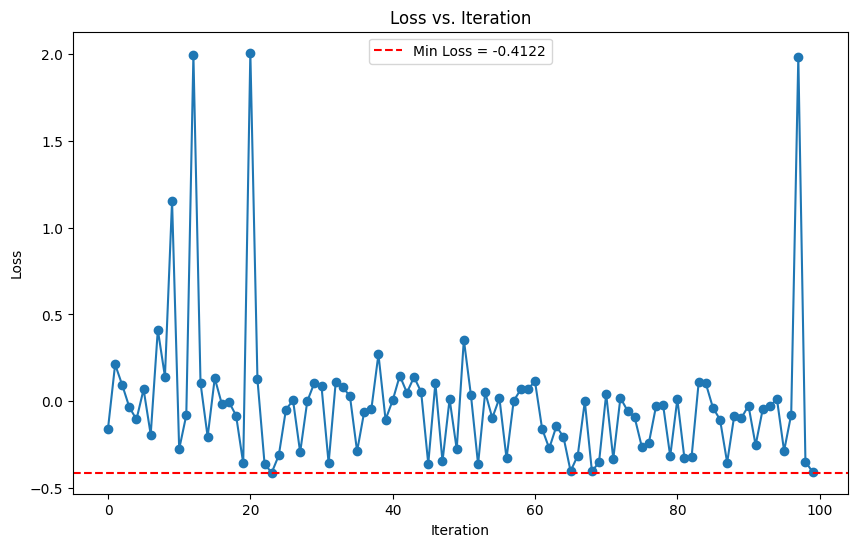

In [2]:
import matplotlib.pyplot as plt

# Extract iteration numbers and corresponding losses
iterations = list(range(len(trials.trials)))
losses = [trial['result']['loss'] for trial in trials.trials]

min_loss = min(losses)

plt.figure(figsize=(10, 6))
plt.plot(iterations, losses, marker='o')
plt.axhline(y=min_loss, color='red', linestyle='--', label=f'Min Loss = {min_loss:.4f}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs. Iteration')
# plt.grid(True)
plt.legend()
plt.show()

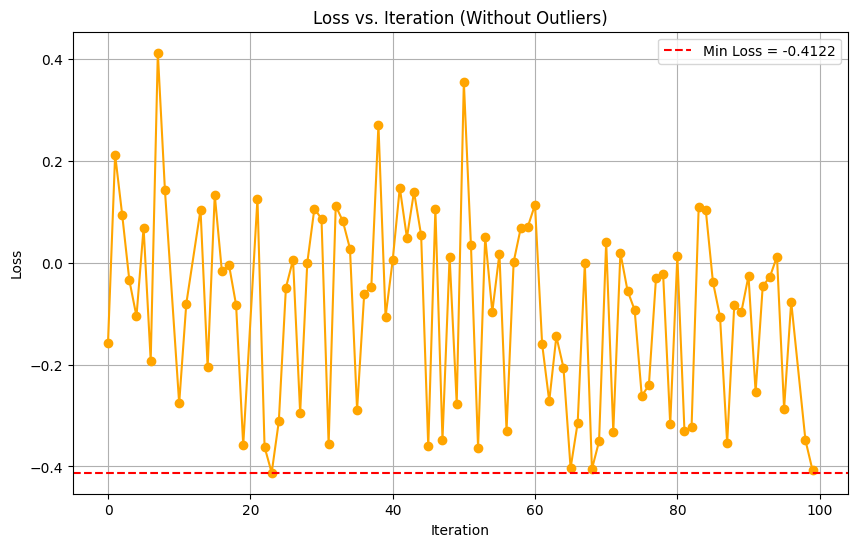

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# Convert losses to NumPy array
losses_array = np.array(losses)

# Calculate z-scores
z_scores = zscore(losses_array)

# Keep only points where z-score is within 2 standard deviations
filtered_indices = np.where(np.abs(z_scores) < 2)[0]

# Filter losses and iterations
filtered_losses = [losses[i] for i in filtered_indices]
filtered_iterations = [iterations[i] for i in filtered_indices]

min_loss = min(losses)

# Plot without outliers
plt.figure(figsize=(10, 6))
plt.plot(filtered_iterations, filtered_losses, marker='o', color='orange')
plt.axhline(y=min_loss, color='red', linestyle='--', label=f'Min Loss = {min_loss:.4f}')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs. Iteration (Without Outliers)')
plt.grid(True)
plt.legend()
plt.show()

In [15]:
loss_arr = np.array(filtered_losses)
ite_arr = np.array(filtered_iterations)
table = pd.DataFrame({'loss':loss_arr,'iteration':ite_arr})
table.to_csv('loss_ite.csv',index=False)

In [6]:
outlier_indices = [i for i in iterations if i not in filtered_iterations]
print("Outlier Trials:", outlier_indices)

Outlier Trials: [9, 12, 20, 97]


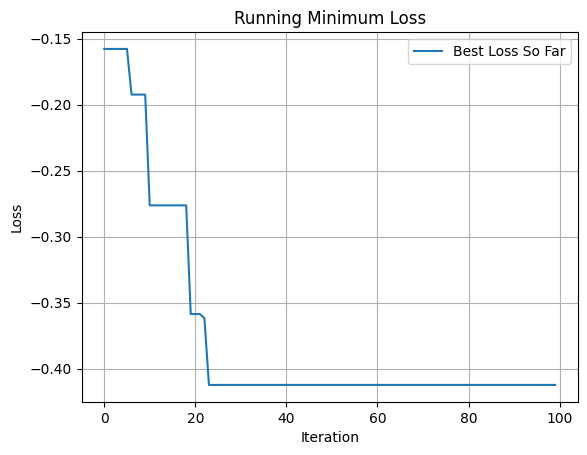

In [12]:
import numpy as np
running_min = np.minimum.accumulate(losses)

plt.plot(running_min, label='Best Loss So Far')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Running Minimum Loss')
plt.grid(True)
plt.legend()

plt.savefig('rml')

plt.show()

In [8]:
running_min

array([-0.15782529, -0.15782529, -0.15782529, -0.15782529, -0.15782529,
       -0.15782529, -0.19241245, -0.19241245, -0.19241245, -0.19241245,
       -0.27628563, -0.27628563, -0.27628563, -0.27628563, -0.27628563,
       -0.27628563, -0.27628563, -0.27628563, -0.27628563, -0.35856829,
       -0.35856829, -0.35856829, -0.36172819, -0.41224912, -0.41224912,
       -0.41224912, -0.41224912, -0.41224912, -0.41224912, -0.41224912,
       -0.41224912, -0.41224912, -0.41224912, -0.41224912, -0.41224912,
       -0.41224912, -0.41224912, -0.41224912, -0.41224912, -0.41224912,
       -0.41224912, -0.41224912, -0.41224912, -0.41224912, -0.41224912,
       -0.41224912, -0.41224912, -0.41224912, -0.41224912, -0.41224912,
       -0.41224912, -0.41224912, -0.41224912, -0.41224912, -0.41224912,
       -0.41224912, -0.41224912, -0.41224912, -0.41224912, -0.41224912,
       -0.41224912, -0.41224912, -0.41224912, -0.41224912, -0.41224912,
       -0.41224912, -0.41224912, -0.41224912, -0.41224912, -0.41

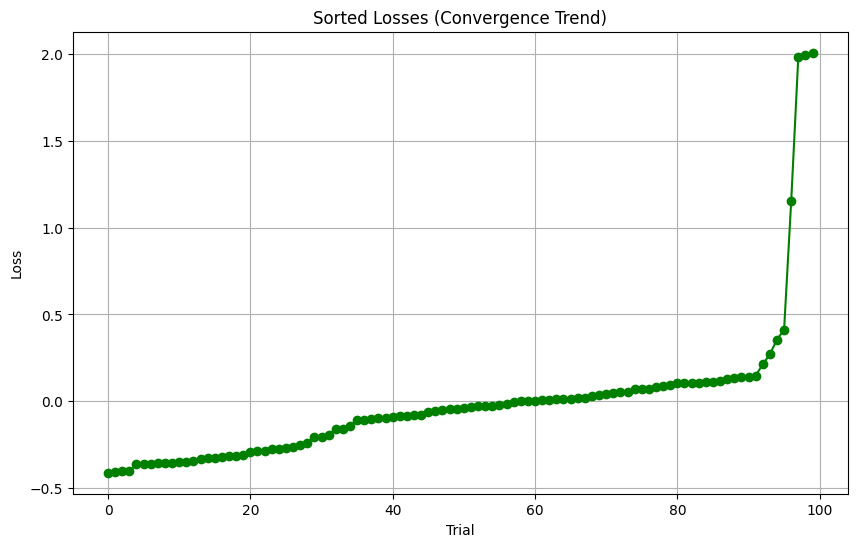

In [9]:
sorted_losses = sorted(losses)

plt.figure(figsize=(10, 6))
plt.plot(sorted_losses, marker='o', color='green')
plt.xlabel('Trial')
plt.ylabel('Loss')
plt.title('Sorted Losses (Convergence Trend)')
plt.grid(True)
plt.show()

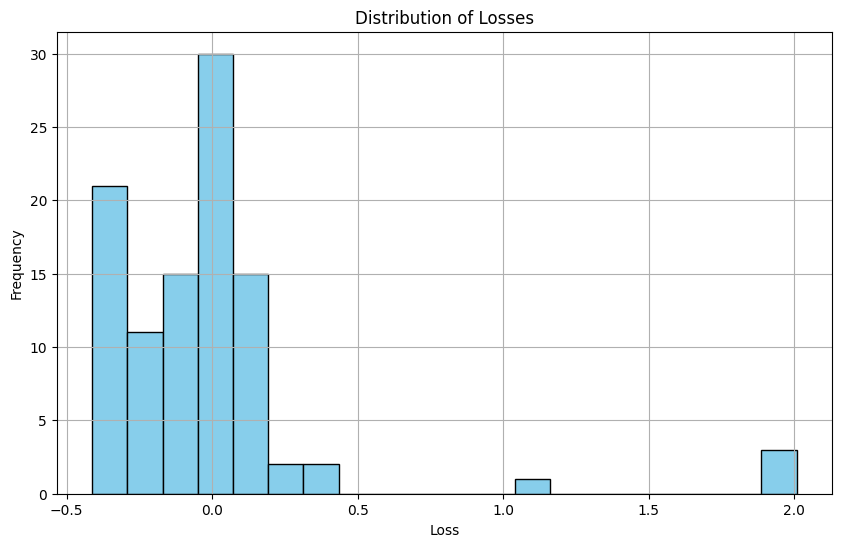

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(losses, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Distribution of Losses')
plt.grid(True)
plt.show()

In [11]:
import pandas as pd

# Extract loss and hyperparameter mappings for all trials
trial_results = []
for trial in trials.trials:
    result = {'loss': trial['result']['loss']}
    result.update({k: v[0] for k, v in trial['misc']['vals'].items()})
    trial_results.append(result)

df_trials = pd.DataFrame(trial_results)

# Sort by loss
top_trials = df_trials.sort_values('loss').head(10)
print(top_trials)

        loss  batch_size  learning_rate
23 -0.412249           3       0.002804
99 -0.407592           3       0.002736
68 -0.405127           3       0.002527
65 -0.403284           3       0.002688
52 -0.363224           3       0.002861
22 -0.361728           3       0.002615
45 -0.360792           3       0.003319
19 -0.358568           3       0.003452
31 -0.356828           3       0.003435
87 -0.354024           3       0.004415
